# Utilization of DenseNet201 for diagnosis of breast abnormality

**Abstract:** As one of the leading killers of females, breast cancer has become one of the heated research topics in the community of clinical medical science and computer science. In the clinic, mammography is a publicly accepted technique to detect early abnormalities such as masses and distortions in breast leading to cancer. Interpreting the images, however, is time-consuming and error-prone for radiologists considering artificial factors including potential fatigue. To improve radiologists’ working efficiency, we developed a semi-automatic computer-aided diagnosis system to classify mammograms into normality and abnormality and thus to ease the process of making a diagnosis of breast cancer. Through transferring deep convolutional neural network DenseNet201 on the basis of suspicious regions provided by radiologists into our system, we obtained the network we termed DenseNet201-C, which achieved a high diagnostic accuracy of 92.73%. The comparison results between our method and the other five methods show that our method achieved the highest accuracy.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import imageio
import shutil
import tensorflow as tf
import numpy as np
import cv2

from PIL import Image

2025-08-24 17:57:52.613337: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-24 17:57:52.613481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-24 17:57:52.742812: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def pipeline(image, label):
    if tf.executing_eagerly():
      opened_image = opening(image.numpy(), element)   # Apply morphological Openess
      mask = create_binarized_mask(opened_image) # Create the Binary Mask
      image = opened_image * mask
    return image, label

In [3]:
def scheduler(epoch, lr):
     if epoch % 10 == 0:
         return lr - 0.01
     else:
         return lr

In [4]:
def evaluate(model, validation):
  m = tf.keras.metrics.Accuracy()
  for image, label in validation:
      pred = model.predict(image)
      pred = tf.constant(pred > 0.5, dtype=tf.int64)

      m.update_state(pred, tf.expand_dims(label, 1))

  return m.result()

In [5]:
def init_model(freeze=False):
  pretrained_model = tf.keras.applications.densenet.DenseNet201(
        include_top=False,
        weights='imagenet',
        input_tensor=None,
        input_shape=None,
        pooling=None,
        classes=None,
        classifier_activation=None
    )
  if freeze:
    for layer in pretrained_model.layers:
        layer.trainable = False

  last_layer = pretrained_model.get_layer('conv5_block32_concat')
  x = tf.keras.layers.GlobalAveragePooling2D()(last_layer.output)
  x =  tf.keras.layers.Flatten()(x)
  x =  tf.keras.layers.Dropout(0.5)(x)
  out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
  out

  return tf.keras.Model(pretrained_model.input, out)

# Converting to PNG and saving to location

Creating a temporary directory to store the images in PNG format

In [6]:
final_dir = os.path.join('/kaggle/working/AllPNGs')
os.makedirs(final_dir, exist_ok=True)

Convertendo de .dcm para .png, e salvando as imagens no novo diretório

In [7]:
directory = "/kaggle/input/inbreast-dataset/INbreast Release 1.0/AllDICOMs/"

for filename in os.listdir(directory):
    if filename.endswith(".dcm"): 
        ds = pydicom.dcmread(os.path.join(directory, filename))
        pixel_array = ds.pixel_array
        name_parts = filename.split("_")        
        new_filename = name_parts[0]
        output_path = f"/kaggle/working/AllPNGs/{new_filename}.png"
        imageio.imwrite(output_path, pixel_array)

# Criando a divisão das classes

In [8]:
os.listdir('/kaggle/input/inbreast-dataset/INbreast Release 1.0')

['INbreast.csv',
 'README.txt',
 'inbreast.pdf',
 'PectoralMuscle',
 'INbreast.xls',
 'AllXML',
 'AllDICOMs',
 'AllROI',
 'MedicalReports']

In [9]:
raw_csv = pd.read_csv("/kaggle/input/inbreast-dataset/INbreast Release 1.0/INbreast.csv", delimiter=';')
raw_csv = raw_csv.rename(columns={'File Name':'FileName'})
raw_csv.head(3)

,Patient ID,Patient age,Laterality,View,Acquisition date,FileName,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1


In [10]:
raw_csv_ = pd.read_csv("/kaggle/input/inbreast-roi-yolov8l/INBREAST-Mammography/description.csv")
raw_csv_ = raw_csv_.rename(columns={'File name':'FileName'})
raw_csv.head(3)

,Patient ID,Patient age,Laterality,View,Acquisition date,FileName,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1


In [11]:
raw_csv = pd.merge(
    raw_csv,
    raw_csv_[['FileName','Lesion annotation status']],
    how='left',
    on = 'FileName'
)
raw_csv.head(3)

,Patient ID,Patient age,Laterality,View,Acquisition date,FileName,ACR,Bi-Rads,Lesion annotation status
0,removed,removed,R,CC,201001,22678622,4,1,NO ANNOTATION (NORMAL)
1,removed,removed,L,CC,201001,22678646,4,3,CANCER
2,removed,removed,R,MLO,201001,22678670,4,1,NO ANNOTATION (NORMAL)


In [12]:
data_info = raw_csv.copy()

In [13]:
ALL_CLASSES = data_info['Lesion annotation status']
ABNORMAL_CLASSES = ALL_CLASSES !='NO ANNOTATION (NORMAL)'
abnormal_images = data_info[ABNORMAL_CLASSES]
data_info.loc[ABNORMAL_CLASSES, ["NEW_CLASS"]] = ["ABNORM"] * abnormal_images.shape[0]
data_info["NEW_CLASS"] = data_info["NEW_CLASS"].fillna("NORM")
data_info = data_info.drop(columns=['Lesion annotation status'])

In [14]:
IMAGE_DIR = "/kaggle/working/AllPNGs/"
SAVE_DIR = "inbreast"
class_list = ['NORM', 'ABNORM']
for class_name in class_list:
  final_dir = os.path.join(SAVE_DIR, class_name)
  os.makedirs(final_dir, exist_ok=True)


for refnum, class_name in data_info.loc[:, ['FileName','NEW_CLASS']].values:
    in_filename = f"{refnum}.png"
    out_filename = f"{refnum}.png"
   
    img_png = Image.open(os.path.join(IMAGE_DIR, in_filename)).convert("RGB")
    final_dir = os.path.join(SAVE_DIR, class_name)

    img_png.save(os.path.join(final_dir, out_filename))
    # shutil.copyfile(os.path.join(IMAGE_DIR, filename),
    #                 os.path.join(final_dir, out_filename))


In [15]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation((0, 1)),
])

In [16]:
directory = "/kaggle/working/inbreast"
for dir in os.listdir(directory):
  new_path = os.path.join(directory, dir)

  if dir == "ABNORM":
    for example in os.listdir(new_path):
        example_path = os.path.join(new_path, example)
        img_example = Image.open(example_path).convert("RGB")
        augmented_image = data_augmentation(np.asarray(img_example))
        out_filename = "aug_" + example

        cv2.imwrite(os.path.join(new_path, out_filename), augmented_image.numpy())
      #Image.save(, )


In [17]:
training_data, validation_data = tf.keras.utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=8,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="both",
    interpolation="bilinear",
)

Found 753 files belonging to 2 classes.
Using 603 files for training.
Using 150 files for validation.


In [18]:
training_dataset = training_data.map(pipeline)
validation_dataset = validation_data.map(pipeline)

In [19]:
tf_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)

# Results with freeze=False

In [20]:
accs = []
for i in range(5):
  model = init_model(freeze=False)
  model.compile(
    loss=tf.keras.losses.binary_crossentropy ,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['acc'],

  )
  history = model.fit(
      training_dataset,
      epochs=5,
      verbose = 1,
  )
  result = evaluate(model, validation_dataset)
  accs.append(result)
  print("Accuracy: ", result)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


2025-08-24 18:21:07.401394: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module a_inference_one_step_on_data_182053__.89165] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-08-24 18:21:37.721860: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m30.320618914s

********************************
[Compiling module a_inference_one_step_on_data_182053__.89165] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
I0000 00:00:1756059697.724492      68 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - acc: 0.9054 - loss: 0.6054

2025-08-24 18:26:22.560359: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m29.435844034s

********************************
[Compiling module a_inference_one_step_on_data_182053__.89165] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


76/76 ━━━━━━━━━━━━━━━━━━━━ 669s 4s/step - acc: 0.9054 - loss: 0.6000
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 287ms/step - acc: 0.9090 - loss: 0.3504
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - acc: 0.9002 - loss: 0.2988
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 285ms/step - acc: 0.8992 - loss: 0.3428
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 25s 289ms/step - acc: 0.9004 - loss: 0.3508
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106m

In [21]:
np.mean(accs).round(6), np.std(accs).round(6), np.median(accs).round(6)

(0.92, 0.0, 0.92)

In [22]:
np.std(accs)

5.9604645e-08

# Resultados com freeze=True

In [23]:
accs_freeze = []
for i in range(5):
  model = init_model(freeze=True)
  model.compile(
    loss=tf.keras.losses.binary_crossentropy ,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['acc'],

  )
  history = model.fit(
      training_dataset ,
      epochs=5,
      verbose = 1,
  )
  result = evaluate(model, validation_dataset)
  accs_freeze.append(result)
  print("Accuracy: ", result)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 85s 521ms/step - acc: 0.8143 - loss: 1.2920
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - acc: 0.8650 - loss: 0.9325
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step - acc: 0.8101 - loss: 0.8787
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - acc: 0.8739 - loss: 1.0198
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 22s 258ms/step - acc: 0.8564 - loss: 0.9685
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━

In [24]:
np.mean(accs_freeze).round(3), np.std(accs_freeze).round(3), np.median(accs_freeze).round(3)

(0.92, 0.0, 0.92)

In [25]:
np.std(accs_freeze)

5.9604645e-08

# Analyze Model Performance 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


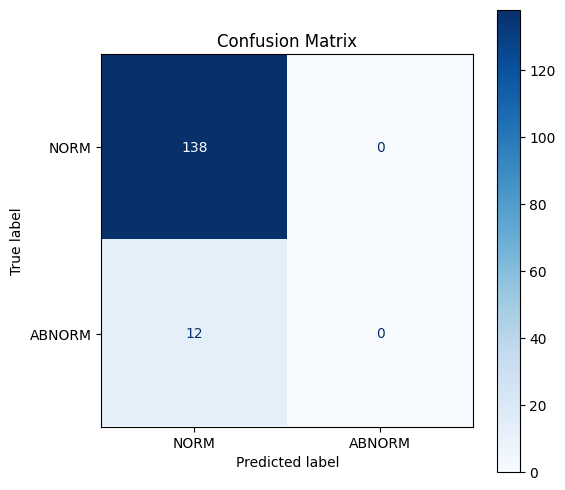

In [26]:
# plot patches of mammograms along the model's confidence score 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataset, class_names=['NORM', 'ABNORM']):
    y_true = []
    y_pred = []

    # Collect predictions
    for images, labels in dataset:
        preds = model.predict(images)
        preds = (preds > 0.5).astype(int).flatten()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", ax=ax, values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

# Example usage
plot_confusion_matrix(model, validation_dataset)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


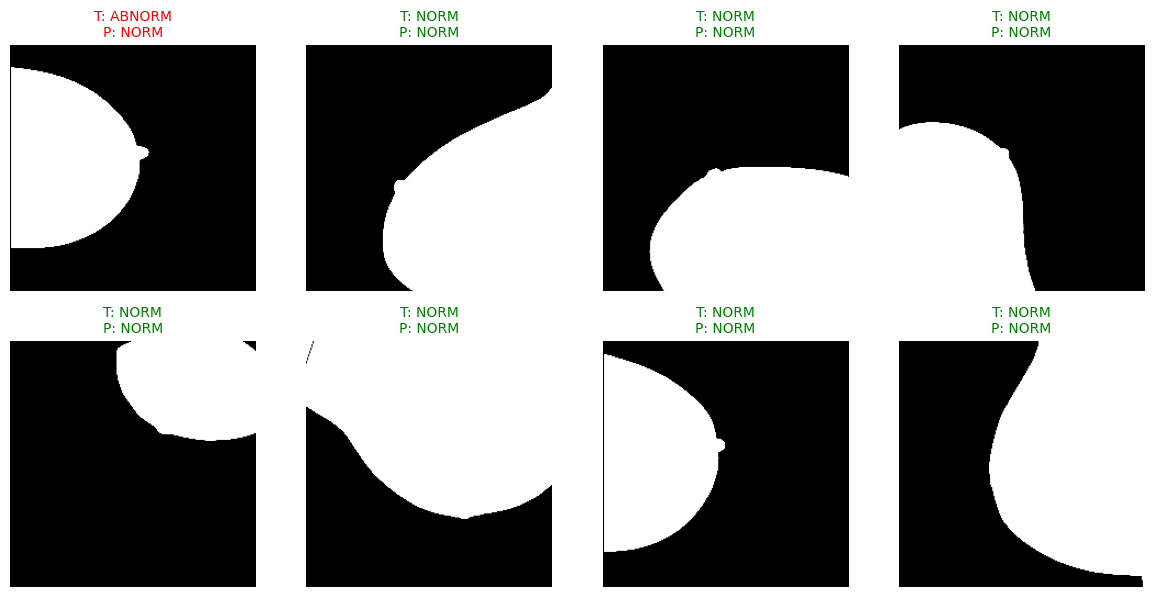

In [27]:
import matplotlib.pyplot as plt

def plot_predictions_grid(model, dataset, class_names=['NORM', 'ABNORM'], n_images=16):
    plt.figure(figsize=(12, 12))
    
    images_shown = 0
    for images, labels in dataset.take(1):  # take one batch
        preds = model.predict(images)
        preds = (preds > 0.5).astype(int).flatten()

        for i in range(min(n_images, len(images))):
            ax = plt.subplot(int(n_images**0.5), int(n_images**0.5), i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[labels[i].numpy()]
            pred_label = class_names[preds[i]]

            color = "green" if true_label == pred_label else "red"
            ax.set_title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=10)
            plt.axis("off")

            images_shown += 1
            if images_shown >= n_images:
                break
    plt.tight_layout()
    plt.show()

# Example usage
plot_predictions_grid(model, validation_dataset, n_images=16)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


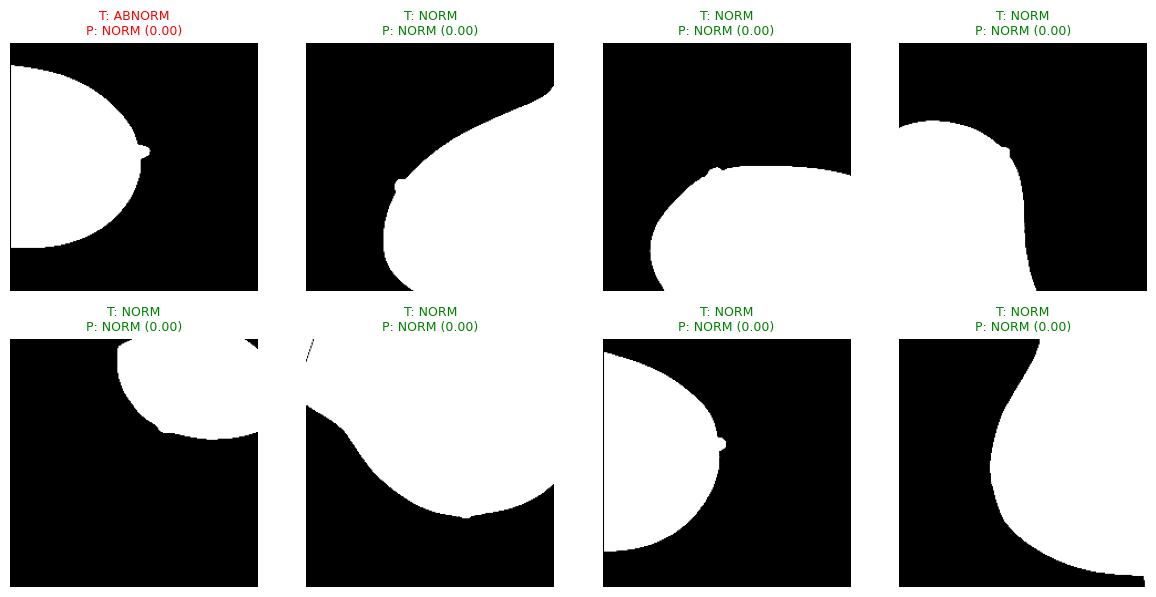

In [28]:
import matplotlib.pyplot as plt

def plot_predictions_grid(model, dataset, class_names=['NORM', 'ABNORM'], n_images=16):
    plt.figure(figsize=(12, 12))
    
    images_shown = 0
    for images, labels in dataset.take(1):  # take one batch
        preds = model.predict(images)
        probs = preds.flatten()  # raw sigmoid outputs
        preds = (preds > 0.5).astype(int).flatten()

        for i in range(min(n_images, len(images))):
            ax = plt.subplot(int(n_images**0.5), int(n_images**0.5), i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            true_label = class_names[labels[i].numpy()]
            pred_label = class_names[preds[i]]
            confidence = probs[i]

            # Green if correct, red if wrong
            color = "green" if true_label == pred_label else "red"

            ax.set_title(
                f"T: {true_label}\nP: {pred_label} ({confidence:.2f})",
                color=color, fontsize=9
            )
            plt.axis("off")

            images_shown += 1
            if images_shown >= n_images:
                break
    plt.tight_layout()
    plt.show()

# Example usage
plot_predictions_grid(model, validation_dataset, n_images=16)
